In [1]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import shutil

# Root directories to fix
splits = ['train', 'valid', 'test']
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for split in splits:
    split_path = os.path.join(os.getcwd(), split)
    if not os.path.exists(split_path):
        continue
        
    img_dir = os.path.join(split_path, 'images')
    lbl_dir = os.path.join(split_path, 'labels')
    
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)
    
    # Move files to their respective subfolders
    for filename in os.listdir(split_path):
        file_path = os.path.join(split_path, filename)
        
        # Skip directories
        if os.path.isdir(file_path):
            continue
            
        if filename.lower().endswith(image_extensions):
            shutil.move(file_path, os.path.join(img_dir, filename))
        elif filename.lower().endswith('.txt') and filename != 'labels.txt':
            shutil.move(file_path, os.path.join(lbl_dir, filename))

print("Dataset folders successfully reorganized into 'images' and 'labels' subdirectories!")

Dataset folders successfully reorganized into 'images' and 'labels' subdirectories!


In [3]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Search automatically for best.pt across your runs folder
model_path = None
for root, dirs, files in os.walk("runs"):
    if "best.pt" in files:
        model_path = os.path.join(root, "best.pt")
        break

if model_path is None:
    print("Training is still in progress! Wait for epoch 30/30 to complete before running predictions.")
else:
    print(f"Loaded trained model from: {model_path}")
    best_model = YOLO(model_path)

    # 2. Grab test image
    test_img_folder = "test/images"
    if os.path.exists(test_img_folder) and os.listdir(test_img_folder):
        sample_img = os.path.join(test_img_folder, os.listdir(test_img_folder)[0])

        # 3. Predict bounding boxes
        results = best_model.predict(source=sample_img, conf=0.25)

        # 4. Display annotated output image
        for r in results:
            im_array = r.plot()
            im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(10, 6))
            plt.imshow(im_rgb)
            plt.axis("off")
            plt.show()

Training is still in progress! Wait for epoch 30/30 to complete before running predictions.


In [4]:
import os

project_path = r"C:\Users\SONAKSHI GOYAL\Desktop\project"

for folder in ["train", "valid", "val", "test"]:
    path = os.path.join(project_path, folder)

    if os.path.exists(path):
        print(f"\n{folder} folder exists")

        for root, dirs, files in os.walk(path):
            txt_files = [f for f in files if f.endswith(".txt")]
            if txt_files:
                print(root, "->", len(txt_files), "label files")
    else:
        print(f"\n{folder} folder NOT FOUND")


train folder exists

valid folder exists

val folder NOT FOUND

test folder exists


In [5]:
import os

project_path = r"C:\Users\SONAKSHI GOYAL\Desktop\project"

for folder in ["train", "valid", "test"]:
    path = os.path.join(project_path, folder)

    print(f"\n--- {folder} ---")

    for root, dirs, files in os.walk(path):
        print("Folder:", root)
        print("Files:", files[:10])


--- train ---
Folder: C:\Users\SONAKSHI GOYAL\Desktop\project\train
Files: ['_classes.csv']
Folder: C:\Users\SONAKSHI GOYAL\Desktop\project\train\images
Files: ['frame_0_segment_-0-0-17-09-2023-mp4_15_30-mp4_jpg.rf.71231d0b69a638c1986f63875d5471eb.jpg', 'frame_0_segment_-0-1-02-09-2023-mp4_150_165-mp4_jpg.rf.549e1eac6e87f5d4e81c34c1ff34307a.jpg', 'frame_0_segment_-0-1-06-11-2023-mp4_90_105-mp4_jpg.rf.73b8cf5697d359c39adb0898f0290ba3.jpg', 'frame_0_segment_-0-1-19-08-2023-mp4_15_30-mp4_jpg.rf.147e0bc18ed4de2aabed493529a377be.jpg', 'frame_0_segment_-0-2-05-08-2023-mp4_30_45-mp4_jpg.rf.81fd20cb2b62fde18d47b3cea6170f27.jpg', 'frame_0_segment_-0-2-05-08-2023-mp4_75_90-mp4_jpg.rf.3f7a51020f4d1aea2b2c1a823592e71b.jpg', 'frame_0_segment_-0-2-05-08-2023-mp4_90_105-mp4_jpg.rf.049e95a91fdedf7c4a810fef397a33f7.jpg', 'frame_0_segment_-2-1-22-07-2023-mp4_30_45-mp4_jpg.rf.aa893a0fcc2ee7d66feeffc23b524a10.jpg', 'frame_0_segment_-21-21-0-2-01-12-2023-mp4_60_75-mp4_jpg.rf.2172813a692a8db40d2e3e2a67bbb0

In [6]:
import pandas as pd
import os

project_path = r"C:\Users\SONAKSHI GOYAL\Desktop\project"

for folder in ["train", "valid", "test"]:

    csv_path = os.path.join(
        project_path, folder, "_classes.csv"
    )

    df = pd.read_csv(csv_path)

    print(f"\n--- {folder.upper()} ---")
    print("Classes:", list(df.columns[1:]))
    print("Number of images:", len(df))


--- TRAIN ---
Classes: [' Unlabeled', ' football-shot', ' game', ' goal', ' lower', ' top']
Number of images: 2749

--- VALID ---
Classes: [' Unlabeled', ' football-shot', ' game', ' goal', ' lower', ' top']
Number of images: 785

--- TEST ---
Classes: [' Unlabeled', ' football-shot', ' game', ' goal', ' lower', ' top']
Number of images: 393


##On whole

In [7]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# Test on an image from your dataset
results = model.predict(
    source=r"C:\Users\SONAKSHI GOYAL\Desktop\project\train\images",
    conf=0.25,
    save=True
)

print("Detection completed!")


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2749 C:\Users\SONAKSHI GOYAL\Desktop\project\train\images\frame_0_segment_-0-0-17-09-2023-mp4_15_30-mp4_jpg.rf.71231d0b69a638c1986f63875d5471eb.jpg: 384x640 14 persons, 208.6ms
image 2/2749 C:\Users\SONAKSHI GOYAL\Desktop\project\train\images\frame_0_segment_-0-1-02-09-2023-mp4_150_165-mp4_jpg.rf.549e1eac6e87f5d4e81c34c1ff34307a.jpg: 384x640 18 persons, 51.0ms
image 3/2749 C:\Users\SONAKSHI GOYAL\Desktop\project\train\images\frame_0_segment_-0-1-06-1

KeyboardInterrupt: 

#On one img

In [8]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

image_path = r"C:\Users\SONAKSHI GOYAL\Desktop\project\train\images"

# Get first image
image = [
    os.path.join(image_path, f)
    for f in os.listdir(image_path)
    if f.endswith((".jpg", ".png", ".jpeg"))
][0]

results = model.predict(
    source=image,
    conf=0.25,
    save=True,
    verbose=False
)

print("Detection completed!")

Results saved to C:\Users\SONAKSHI GOYAL\Desktop\project\runs\detect\predict-7
Detection completed!


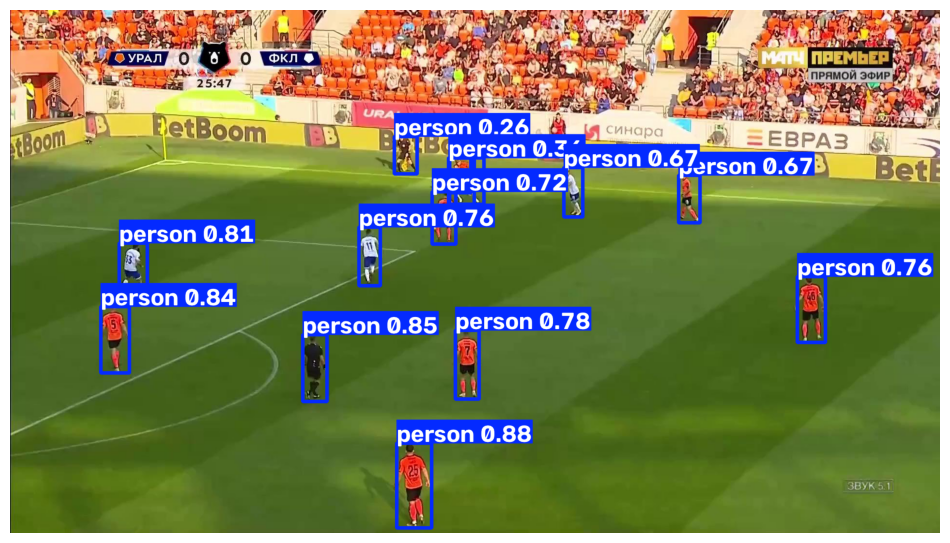

In [9]:
import matplotlib.pyplot as plt

# Display detection result
annotated_image = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.show()

In [10]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

image_dir = r"C:\Users\SONAKSHI GOYAL\Desktop\project\train\images"
label_dir = r"C:\Users\SONAKSHI GOYAL\Desktop\project\auto_labels"

os.makedirs(label_dir, exist_ok=True)

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:100]

for filename in image_files:

    image_path = os.path.join(image_dir, filename)

    results = model.predict(
        source=image_path,
        conf=0.40,
        classes=[0],
        verbose=False
    )

    result = results[0]

    label_path = os.path.join(
        label_dir,
        os.path.splitext(filename)[0] + ".txt"
    )

    with open(label_path, "w") as file:

        for box in result.boxes:

            x_center, y_center, width, height = (
                box.xywhn[0].cpu().tolist()
            )

            # Class 0 = player
            file.write(
                f"0 {x_center} {y_center} "
                f"{width} {height}\n"
            )

print("Draft labels created!")

Draft labels created!


In [11]:
import os

label_dir = r"C:\Users\SONAKSHI GOYAL\Desktop\project\auto_labels"

label_files = os.listdir(label_dir)

total_labels = 0
empty_files = 0

for filename in label_files:
    path = os.path.join(label_dir, filename)

    with open(path, "r") as file:
        lines = file.readlines()

    if len(lines) == 0:
        empty_files += 1

    total_labels += len(lines)

print("Total label files:", len(label_files))
print("Total player detections:", total_labels)
print("Empty label files:", empty_files)

Total label files: 100
Total player detections: 839
Empty label files: 0


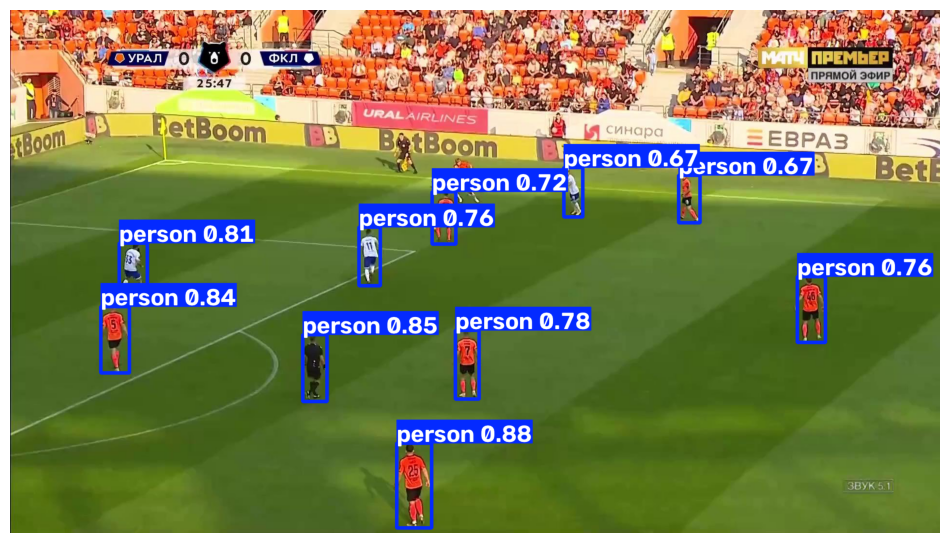

In [12]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

model = YOLO("yolov8n.pt")

image_dir = r"C:\Users\SONAKSHI GOYAL\Desktop\project\train\images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_path = os.path.join(image_dir, image_files[0])

results = model.predict(
    source=image_path,
    conf=0.40,
    classes=[0],
    verbose=False
)

annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.show()

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.predict(
    source=image,
    conf=0.10,
    classes=[0, 32],  # person + sports ball
    save=True,
    verbose=False
)

print("Detection completed!")

for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    print(
        f"Class: {model.names[class_id]}, "
        f"Confidence: {confidence:.2f}"
    )

Results saved to C:\Users\SONAKSHI GOYAL\Desktop\project\runs\detect\predict-8
Detection completed!
Class: person, Confidence: 0.88
Class: person, Confidence: 0.85
Class: person, Confidence: 0.84
Class: person, Confidence: 0.81
Class: person, Confidence: 0.78
Class: person, Confidence: 0.76
Class: person, Confidence: 0.76
Class: person, Confidence: 0.72
Class: person, Confidence: 0.67
Class: person, Confidence: 0.67
Class: person, Confidence: 0.36
Class: person, Confidence: 0.36
Class: person, Confidence: 0.27
Class: person, Confidence: 0.26


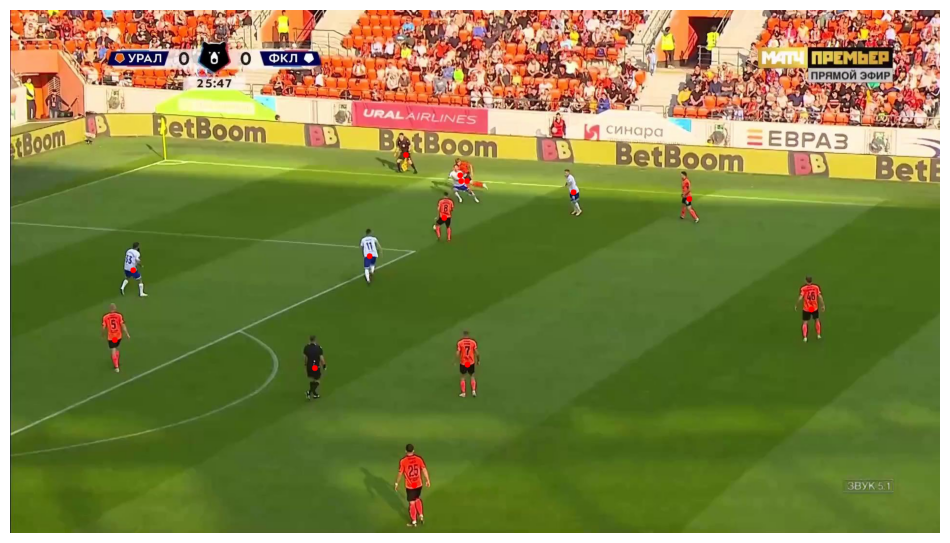

Total center points: 14


In [14]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image)

boxes = results[0].boxes
points = []

for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()

    # Center of bounding box
    px = int((x1 + x2) / 2)
    py = int((y1 + y2) / 2)

    points.append((px, py))

    # Draw center point
    cv2.circle(img, (px, py), 6, (0, 0, 255), -1)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Total center points:", len(points))

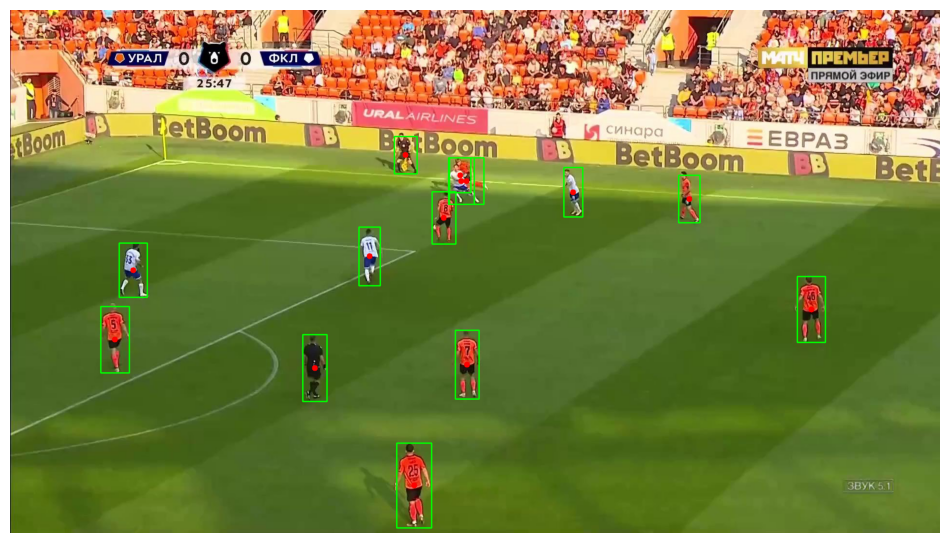

Total center points: 14


In [15]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image)

boxes = results[0].boxes
points = []

for box in boxes:
    x1, y1, x2, y2 = map(
        int, box.xyxy[0].cpu().tolist()
    )

    # Calculate center
    px = (x1 + x2) // 2
    py = (y1 + y2) // 2

    points.append((px, py))

    # Draw bounding box (green)
    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw center point (red)
    cv2.circle(
        img,
        (px, py),
        6,
        (0, 0, 255),
        -1
    )

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Total center points:", len(points))

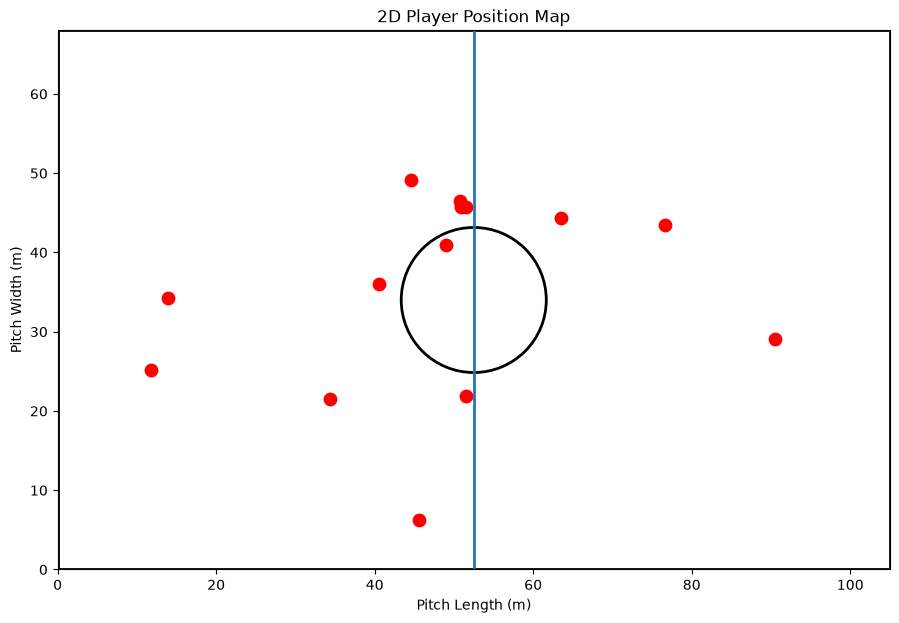

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Image dimensions
img_height, img_width = img.shape[:2]

# Create football pitch
fig, ax = plt.subplots(figsize=(12, 7))

# Pitch dimensions (standard visualization)
pitch_length = 105
pitch_width = 68

ax.set_xlim(0, pitch_length)
ax.set_ylim(0, pitch_width)
ax.set_aspect("equal")

# Pitch boundary
ax.add_patch(
    patches.Rectangle(
        (0, 0),
        pitch_length,
        pitch_width,
        fill=False,
        linewidth=2
    )
)

# Halfway line
ax.plot(
    [pitch_length / 2, pitch_length / 2],
    [0, pitch_width],
    linewidth=2
)

# Center circle
center_circle = patches.Circle(
    (pitch_length / 2, pitch_width / 2),
    9.15,
    fill=False,
    linewidth=2
)

ax.add_patch(center_circle)

# Plot player center points
for px, py in points:

    # Normalize image coordinates
    x_pitch = (px / img_width) * pitch_length
    y_pitch = pitch_width - (py / img_height) * pitch_width

    ax.scatter(
        x_pitch,
        y_pitch,
        s=80,
        color="red"
    )

ax.set_title("2D Player Position Map")
ax.set_xlabel("Pitch Length (m)")
ax.set_ylabel("Pitch Width (m)")

plt.show()